# Python Data Analytics Class Exercise
## Grocery/Retail Data Analysis — SQL Querying & Data Analysis

**Prepared by: Christine Nabisswa**

### Exercise Description

This document presents my completed class exercise using grocery/retail data. The exercise demonstrates the application of SQL querying, data aggregation, filtering, inventory turnover analysis, and cross-tabulation to examine structured retail supply chain and sales data.

### 1. Import the libraries

In [ ]:
import pandas as pd

### 2. Import the data from two csv files as DataFrames `grocery_purchase and grocery_transaction)

In [ ]:
grocery_purchase=pd.read_csv('QVI_purchase_behaviour.csv')

In [ ]:
grocery_transaction=pd.read_csv('QVI_transaction_data.csv')

### 3. Look at the info summary, head of each DataFrame

In [ ]:
grocery_purchase.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [ ]:
grocery_purchase.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [ ]:
grocery_transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [ ]:
grocery_transaction.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


### 4. Check for the unique values and their counts in each column for the two DataFrames

In [ ]:
grocery_purchase.nunique()

,0
LYLTY_CARD_NBR,72637
LIFESTAGE,7
PREMIUM_CUSTOMER,3


In [ ]:
grocery_transaction.nunique()

,0
DATE,364
STORE_NBR,272
LYLTY_CARD_NBR,72637
TXN_ID,263127
PROD_NBR,114
PROD_NAME,114
PROD_QTY,6
TOT_SALES,112


#### grocery transaction has at least two unique values

### 5. Check for duplicates in the two DataFrames

In [ ]:
grocery_purchase[grocery_purchase.duplicated()]

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER


#### No duplicate row in grocery_purchase

In [ ]:
grocery_transaction[grocery_transaction.duplicated()]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
124845,43374,107,107024,108462,45,Smiths Thinly Cut Roast Chicken 175g,2,6.0


#### We have duplicate row in grocery_transaction

In [ ]:
### Remove duplicates from Pandas DataFrame-grocery_transaction

In [ ]:
grocery_transaction.drop_duplicates()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,43410,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


In [ ]:
grocery_transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


### .6 Check for missing data by columns in `grocery_purchase` using the `isna` method

In [ ]:
grocery_purchase.isna().sum()

,0
LYLTY_CARD_NBR,0
LIFESTAGE,0
PREMIUM_CUSTOMER,0


No missing data in this dataset

In [ ]:
grocery_transaction.isna().sum()

,0
DATE,0
STORE_NBR,0
LYLTY_CARD_NBR,0
TXN_ID,0
PROD_NBR,0
PROD_NAME,0
PROD_QTY,0
TOT_SALES,0


No missing data in this dataset

### 7. Check for outliers in `grocery_purchase` using the `describe` method, then look at the histograms of the suspicious columns

In [ ]:
grocery_purchase.describe()

,LYLTY_CARD_NBR
count,7.263700e+04
mean,1.361859e+05
std,8.989293e+04
min,1.000000e+03
25%,6.620200e+04
50%,1.340400e+05
75%,2.033750e+05
max,2.373711e+06


The DataFrame `grocery_purchase` doesn't have any columns that could have outliers, so we are not exploring it.

### 8. Check for outliers in `grocery_transaction` using the `describe` method, then look at the histograms of the suspicious columns

In [ ]:
grocery_transaction.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.000000,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,43464.036260,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
std,105.389282,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226
min,43282.000000,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,43646.000000,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


array([[<Axes: title={'center': 'PROD_NBR'}>,
        <Axes: title={'center': 'PROD_QTY'}>],
       [<Axes: title={'center': 'TOT_SALES'}>, <Axes: >]], dtype=object)

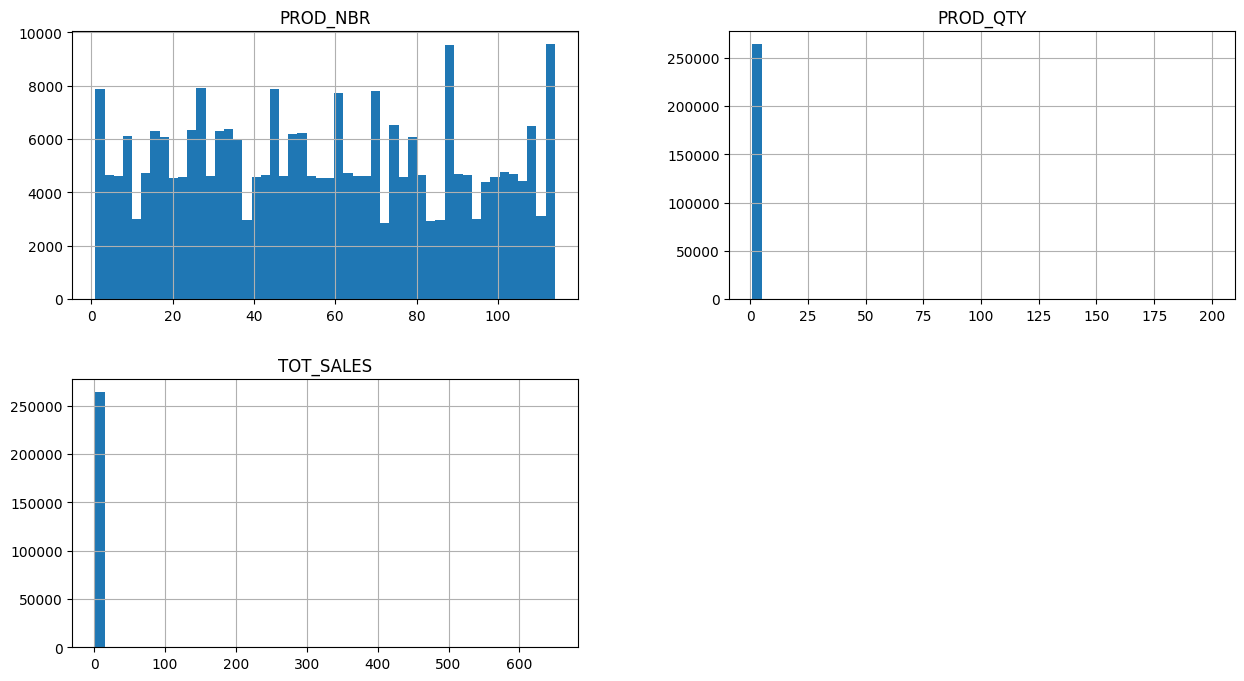

In [ ]:
grocery_transaction[['PROD_NBR', 'PROD_QTY', 'TOT_SALES']].hist(bins=50, figsize=(15,8))

In [ ]:
grocery_transaction[grocery_transaction['PROD_NBR'] > 100]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
11,43332,8,8294,8221,114,Kettle Sensations Siracha Lime 150g,5,23.0
24,43327,38,38142,34181,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,2,9.2
26,43331,39,39167,35638,111,Smiths Chip Thinly Cut Original 175g,2,6.0
39,43330,55,55072,48878,107,Smiths Crinkle Cut French OnionDip 150g,1,2.6
...,...,...,...,...,...,...,...,...
264748,43284,268,268228,264647,102,Kettle Mozzarella Basil & Pesto 175g,1,5.4
264752,43311,268,268365,264802,103,RRD Steak & Chimuchurri 150g,1,2.7
264759,43499,269,269125,265775,107,Smiths Crinkle Cut French OnionDip 150g,2,5.2
264784,43308,270,270002,266605,113,Twisties Chicken270g,2,9.2


In [ ]:
grocery_transaction.loc[grocery_transaction['PROD_NBR'] > 100, 'PROD_NAME'].value_counts()

,count
PROD_NAME,
Kettle Mozzarella Basil & Pesto 175g,3304
Kettle Tortilla ChpsHny&Jlpno Chili 150g,3296
Tyrrells Crisps Ched & Chives 165g,3268
Infuzions Thai SweetChili PotatoMix 110g,3242
Pringles Barbeque 134g,3210
Twisties Chicken270g,3170
Kettle Sensations Siracha Lime 150g,3127
Smiths Chip Thinly Cut Original 175g,1614
Woolworths Cheese Rings 190g,1516


In [ ]:
grocery_transaction[grocery_transaction['PROD_QTY'] > 0]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,43410,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


In [ ]:
grocery_transaction.loc[grocery_transaction['PROD_QTY'] > 0, 'PROD_QTY'].value_counts()

,count
PROD_QTY,
2,236039
1,27518
5,450
3,430
4,397
200,2


In [ ]:
grocery_transaction[grocery_transaction['TOT_SALES'] > 0]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,43410,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


In [ ]:
grocery_transaction.loc[grocery_transaction['TOT_SALES'] > 0, 'TOT_SALES'].value_counts()

,count
TOT_SALES,
9.2,22821
7.4,22513
6.0,20798
7.6,20212
8.8,19900
...,...
9.3,3
6.9,3
12.4,2


### 9. Convert column `DATE` in `grocery_transaction` into datetime dtypes

In [ ]:
grocery_transaction['DATE']=pd.to_datetime(grocery_transaction['DATE'])

In [ ]:
grocery_transaction.dtypes

,0
DATE,datetime64[ns]
STORE_NBR,int64
LYLTY_CARD_NBR,int64
TXN_ID,int64
PROD_NBR,int64
PROD_NAME,object
PROD_QTY,int64
TOT_SALES,float64


### 10. Merge (left join) `grocery_purchase` and `grocery_transaction` into a new DataFrame called `purchase_behaviour_transaction` using their common column

In [ ]:
purchase_behaviour_transaction = pd.merge(grocery_purchase, grocery_transaction, on='LYLTY_CARD_NBR', how='left')

In [ ]:
purchase_behaviour_transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   LYLTY_CARD_NBR    264836 non-null  int64         
 1   LIFESTAGE         264836 non-null  object        
 2   PREMIUM_CUSTOMER  264836 non-null  object        
 3   DATE              264836 non-null  datetime64[ns]
 4   STORE_NBR         264836 non-null  int64         
 5   TXN_ID            264836 non-null  int64         
 6   PROD_NBR          264836 non-null  int64         
 7   PROD_NAME         264836 non-null  object        
 8   PROD_QTY          264836 non-null  int64         
 9   TOT_SALES         264836 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(5), object(3)
memory usage: 20.2+ MB


After doing the left join, there is no missing data between purchase behaviour and transaction data. All columns have 264836 count.

In [ ]:
### To check the size of packages and brand names

In [ ]:
purchase_behaviour_transaction.size

2648360